# Causal Inference
Why hunting correlation stars is not sufficient


![](https://raw.githubusercontent.com/firrm/DAI/main/assets/2723_robberies-in-alaska_correlates-with_professor-salaries-in-the-us.png)

Simply observing correlation is ok, but as soon as you start making decisions based on correlation, you are in trouble. Decision-making needs causality. So what is causality and how do we infer it?

# Defining causal effects

### Correlation vs. Causality
- Correlation refers to the statistical relationship between two variables, where a change in one variable is associated with a change in the other.
- Causality, on the other hand, implies that a change in one variable directly causes a change in the other variable.
- It is important to remember that correlation does not necessarily imply causality.

Assume two worlds: Earth and Not-Earth. On earth when it rains, the grass gets wet. On Not-Earth rain does not affect the surface (due to wired physics).  So rain causes an effect if and only if (iff) raining leads to wet grass cp.
More formally an action A causes an effect on Y iff changing A leads to a change in Y keeping all other variables constant (ceteris paribus, c.p.). We call this an **intervention**: do(A). 

### Causal Effect
- A causal effect is the change in an outcome variable that is directly attributable to a change in a treatment or policy variable.
- Estimating causal effects is the primary goal of many economic studies, as it helps policymakers make informed decisions.

$E[Y | do(A=a)]- E[Y | do(A=a')]$ = Causal Effect of A on Y

### Causal Inference
- Causal inference is the process of determining the causal effect of a treatment or policy on an outcome variable.
- Randomized controlled trials (RCTs) are considered the gold standard for causal inference, as they minimize the influence of confounding factors.
- When RCTs are not feasible, economists rely on quasi-experimental methods such as instrumental variables, difference-in-differences, and regression discontinuity designs to estimate causal effects.

Understanding these concepts is essential for designing and interpreting economic studies that aim to uncover the true causal relationships between variables of interest.


### Real world
In the real world we do not observe non-earth directly, ie. we do not observe the counterfactual. We can only observe the world where we are in. So we need to estimate the counterfactual. This is the fundamental problem of causal inference.

Steps of causal inference:
1. **Modeling**: Define the causal model and assumptions.
2. **Identification**: Determine whether the causal effect can be estimated from the data.
3. **Estimation**: Calculate the causal effect using statistical methods.
4. **Refutation**: Test the validity of the causal effect estimate using sensitivity analyses or different statistical methods.
5. **Decision**: Make decisions based on the estimated causal effect.

The following example demonstrates how to perform causal inference using the DoWhy library in Python and follows the dowhy tutorial.

In [1]:
!pip install -q -r https://raw.githubusercontent.com/firrm/DAI/main/requirements_colab.txt #ensure that the required packages are installed
!pip install -q dowhy

# Monkey-patch dowhy.datasets for numpy 2.x compatibility
# (np.vectorize requires functions returning scalars, not 1-element arrays)
import dowhy.datasets as _ds
from numpy.random import choice as _choice
from scipy.special import expit as _expit
def _patched_c2b(x, stochastic=True):
    p = float(_expit(x))
    return int(_choice([0, 1], p=[1 - p, p])) if stochastic else int(p > 0.5)
def _patched_c2b3(x):
    p = float(_expit(x))
    return int(_choice([0, 1, 2], p=[0.8*(1-p), 0.8*p, 0.2]))
_ds.convert_to_binary = _patched_c2b
_ds.stochastically_convert_to_three_level_categorical = _patched_c2b3

from dowhy import CausalModel

#import test data
import dowhy.datasets
data = dowhy.datasets.linear_dataset(
    beta=10,
    num_common_causes=5,
    num_instruments=2,
    num_samples=10000,
    treatment_is_binary=True,
    stddev_treatment_noise=10)
data


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


{'df':        Z0        Z1        W0        W1        W2        W3        W4     v0  \
 0     0.0  0.610961 -0.829824  0.363509 -1.320780 -1.753061 -2.319749  False   
 1     0.0  0.596345 -0.089989  0.746806 -0.199382  0.500379 -0.270898   True   
 2     0.0  0.874193 -2.468106  1.108309  0.569157  0.406613  0.370001  False   
 3     0.0  0.861853 -0.005839 -0.534909  0.406937  2.135909 -0.650826   True   
 4     0.0  0.436120  0.792637  0.385645 -0.442194  0.577574 -0.502157  False   
 ...   ...       ...       ...       ...       ...       ...       ...    ...   
 9995  0.0  0.104019 -0.947450 -0.593644  0.460451 -0.401057 -1.225672   True   
 9996  0.0  0.333079  0.543282  0.353565 -1.218172  0.127199 -1.271094   True   
 9997  0.0  0.404696  0.355009 -1.167106  1.800344 -1.142428  2.031382   True   
 9998  0.0  0.209137 -0.501211 -0.386995  0.233325 -1.623210  0.230525  False   
 9999  0.0  0.397373  0.384102  0.272145  0.806958 -0.014078 -1.329165  False   
 
               y  
 

# 1. Modeling

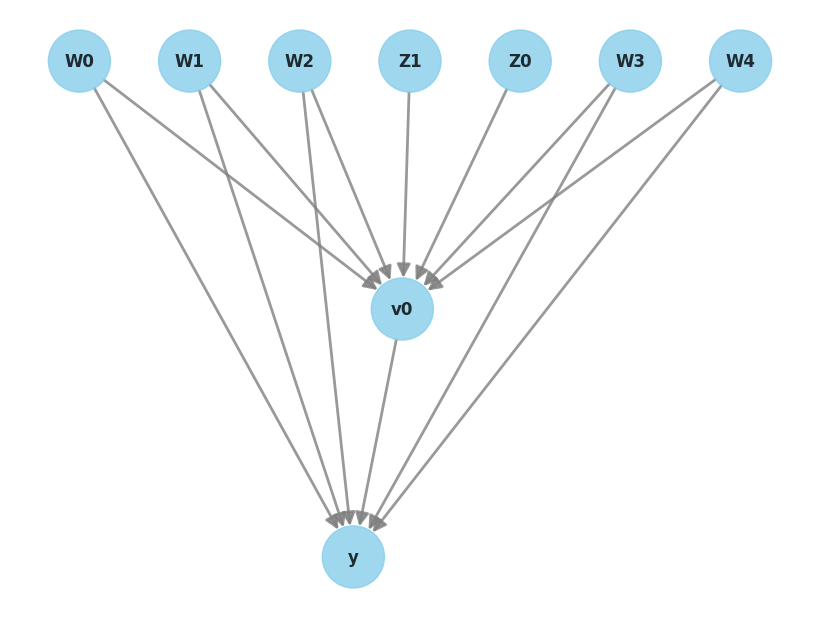

In [2]:
# Create a causal model from the data and given common causes.
model = CausalModel(
    data=data["df"],
    treatment=data["treatment_name"],
    outcome=data["outcome_name"],
    common_causes=data["common_causes_names"],
    instruments=data["instrument_names"]
)   
model.view_model(layout="dot")


# 2. Identification
Identification is the process of determining whether a causal effect can be estimated from the data. In other words, identification asks whether the data contains enough information to estimate the causal effect of interest. For this domain knowledge is essential.

## Adjustment sets (backdoor)
An adjustment set is a set of variables that, when controlled for, allows us to estimate the causal effect of a treatment or policy on an outcome variable.
## Instrumental variable IV (frontdoor)
An instrumental variable (IV) is a variable that is used to estimate the causal effect of a treatment or policy variable on an outcome variable when there is unobserved confounding.

In [3]:
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
  d                       
─────(E[y|W4,W3,W1,W0,W2])
d[v₀]                     
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W4,W3,W1,W0,W2,U) = P(y|v0,W4,W3,W1,W0,W2)

### Estimand : 2
Estimand name: iv
Estimand expression:
 ⎡                              -1⎤
 ⎢    d        ⎛    d          ⎞  ⎥
E⎢─────────(y)⋅⎜─────────([v₀])⎟  ⎥
 ⎣d[Z₁  Z₀]    ⎝d[Z₁  Z₀]      ⎠  ⎦
Estimand assumption 1, As-if-random: If U→→y then ¬(U →→{Z1,Z0})
Estimand assumption 2, Exclusion: If we remove {Z1,Z0}→{v0}, then ¬({Z1,Z0}→y)

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
  d                       
─────(E[y|W4,W3,W1,W0,W2])
d[v₀]                     
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W4,W3,W1,W0,W2,U) = P(y|v0,W4,W3,W1,W0,W2)



#3. Estimation
Estimation is the process of calculating the causal effect of a treatment or policy on an outcome variable using statistical methods. There are several methods for estimating causal effects, including regression, matching, and machine learning algorithms.

## Propensity Score Stratification
Propensity score stratification is a method for estimating the causal effect of a treatment or policy on an outcome variable by stratifying the data based on the propensity score and comparing outcomes within each stratum.


In [4]:
# III. Estimate the target estimand using a statistical method.
propensity_strat_estimate = model.estimate_effect(identified_estimand,
                                 method_name="backdoor.dowhy.propensity_score_stratification")

print(propensity_strat_estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
  d                       
─────(E[y|W4,W3,W1,W0,W2])
d[v₀]                     
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W4,W3,W1,W0,W2,U) = P(y|v0,W4,W3,W1,W0,W2)

## Realized estimand
b: y~v0+W4+W3+W1+W0+W2
Target units: ate

## Estimate
Mean value: 9.957538406250519



# 4. Refutation
Refutation is the process of testing the validity of a causal effect estimate by conducting sensitivity analyses or using different statistical methods. Refutation helps ensure that the estimated causal effect is robust and not sensitive to model specifications or assumptions.


# More complex example
[Let's dig in here](https://colab.research.google.com/github/py-why/EconML/blob/main/notebooks/CustomerScenarios/Case%20Study%20-%20Multi-investment%20Attribution%20at%20A%20Software%20Company%20-%20EconML%20%2B%20DoWhy.ipynb)